In [1]:
# Dirichlet‑Process clustering of NDVI time series
# Piece‑wise (Loredo‑style) temporal model
# PyMC implementation with truncated DP and sequential updating

import numpy as np
import pymc as pm
import pytensor.tensor as pt
from matplotlib import pyplot as plt

import scipy.stats as stats

In [2]:
N_SEGMENTS = 23

In [3]:
# ============================================================
# UTILITIES
# ============================================================

def doy_to_bin(doy, n_segments=N_SEGMENTS):
    """Map day-of-year to piecewise bin"""
    return np.floor((doy % 365) / 365 * n_segments).astype(int)

### levanto series NDVI

In [4]:
import pandas as pd

In [5]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [6]:
nSeries = 100

In [7]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

### reconstruyo vector fechas

In [8]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [9]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [10]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [13]:
ndviDataStart+=1

In [14]:
fechas.shape

(430,)

In [15]:
ndviDataStart

8

/tmp/ipykernel_7820/4001357351.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


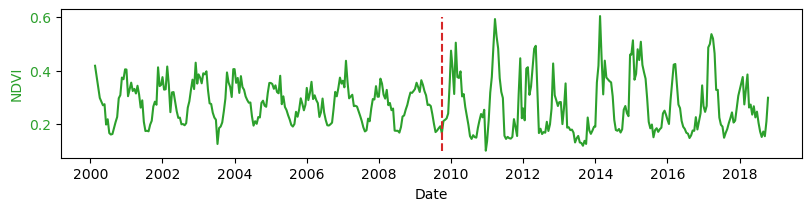

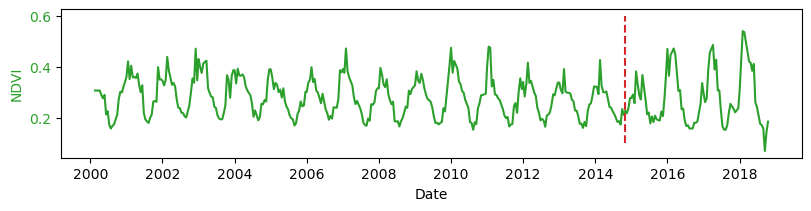

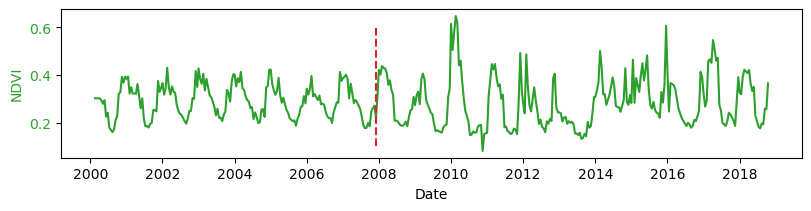

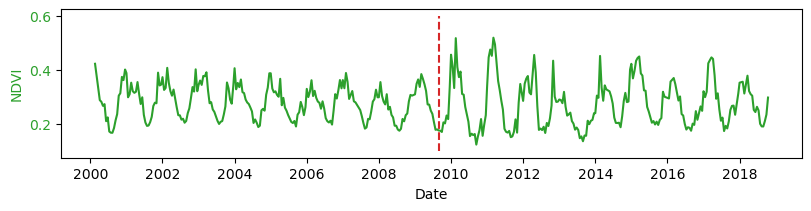

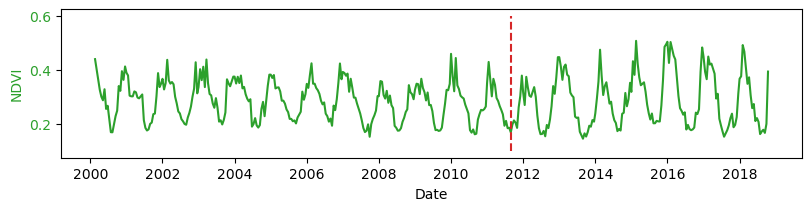

In [16]:
for pixel in testPixel[:5]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    color2 = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, ndvi, color=color1)
    ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
    ax1.tick_params(axis='y', labelcolor=color1)

    fig.show()

### Separo bosque no bosque temporal!

In [17]:
pixel = testPixel[0]
deforestationDate = df['fechaDef'].iloc[pixel]
ndvi = df.iloc[pixel, ndviDataStart-1:].values

In [18]:
deforestationDate.to_julian_date()

2455105.5

In [19]:
fechas.to_julian_date()

Index([2451592.5, 2451608.5, 2451624.5, 2451640.5, 2451656.5, 2451672.5,
       2451688.5, 2451704.5, 2451720.5, 2451736.5,
       ...
       2458263.5, 2458279.5, 2458295.5, 2458311.5, 2458327.5, 2458343.5,
       2458359.5, 2458375.5, 2458391.5, 2458407.5],
      dtype='float64', length=430)

In [44]:
nSeriesToTrain = 30

In [45]:
series = []

ANIOS_ENTRENAMIENTO = 3

for pixel in testPixel[:nSeriesToTrain]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    # defIndex = np.argmax(fechas == deforestationDate)
    defIndex = np.argmin(np.abs(fechas.to_julian_date() - deforestationDate.to_julian_date()))
    
    firstJanIndex = np.argmax(fechas[defIndex:].month == 1) + defIndex #indice del primer enero después de la deforestación
    lastJanIndex = defIndex - np.argmax(np.flip(fechas[:defIndex].month == 1)) -1 #indice del ultimo enero antes de la deforestación

    # bosque = df.iloc[pixel, ndviDataStart-1:defIndex].values # todo el bosque
    bosque = df.iloc[pixel, lastJanIndex-(N_SEGMENTS*ANIOS_ENTRENAMIENTO):lastJanIndex].values # solo los tres años antes de la deforestación
    noBosque = df.iloc[pixel, firstJanIndex:firstJanIndex+(N_SEGMENTS*ANIOS_ENTRENAMIENTO)].values #segmento de tres años primer enero después de la deforestación

    if len(noBosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos después de la deforestación para el pixel {pixel}.")
        continue

    if len(bosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos antes de la deforestación para el pixel {pixel}.")
        continue
    
    if False:
        fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    series.append(bosque)
    series.append(noBosque)

    if False:
        color1 = 'tab:green'
        color2 = 'tab:red'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('NDVI', color=color1)
        ax1.plot(bosque, color=color1)
        ax1.plot(noBosque, color=color2)
        # ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
        ax1.tick_params(axis='y', labelcolor=color1)

        fig.show()

Advertencia: no hay suficientes datos después de la deforestación para el pixel 694.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 547.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 423.


In [46]:
quincenas = np.arange(0, 23*3)

In [47]:
quincenas.shape

(69,)

In [48]:
series = np.array(series)

In [49]:
series.shape

(54, 69)

In [50]:
#quincenas, series, true_clusters = synthetic_series(n_series=30, anios=3, sigma=SIGMA_MODIS)

In [51]:
# true_clusters 
true_clusters = [x%2 for x in range(series.shape[0])]

Text(0.5, 1.0, 'Series reales con clusters conocidos')

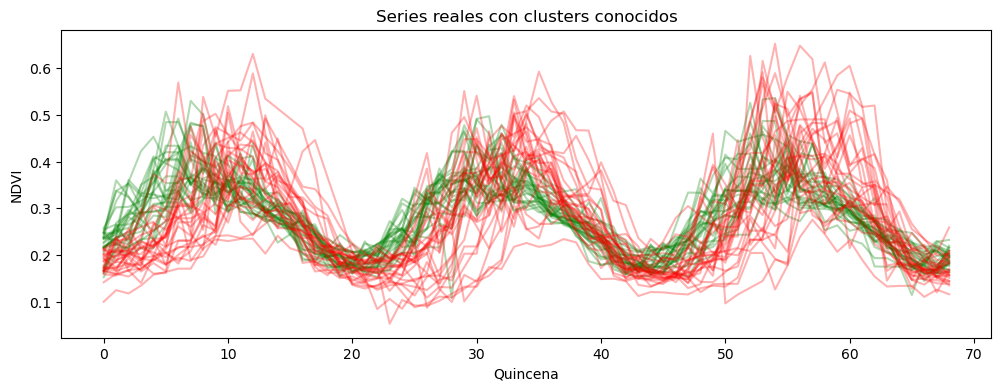

In [52]:
fig = plt.figure(figsize=(12,4))

plt.plot(quincenas, series[0::2, :].T, color='green', alpha=0.3)
plt.plot(quincenas, series[1::2, :].T, color='red', alpha=0.3)
plt.xlabel("Quincena")
plt.ylabel("NDVI")
plt.title("Series reales con clusters conocidos")

In [53]:
series = np.asarray(series, dtype=np.float32)

In [54]:
np.isnan(series).sum()

0

### Inferencia

In [ ]:
def build_model_rw2_v0(Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)
        sigma_rw = pm.HalfNormal("sigma_rw", 0.05)

        # ruido base
        eps = pm.GaussianRandomWalk(
            "eps",
            sigma=sigma_rw,
            shape=(N, T)
        )

        # integración 2 veces → RW2
        x = pm.Deterministic(
            "x",
            eps.cumsum(axis=1).cumsum(axis=1)
        )

        pm.Normal(
            "y",
            mu=x,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [80]:

def build_model_rw3(Y):
    """
    RW2 temporal model for NDVI time series.

    Parameters
    ----------
    Y : array-like
        shape (T,) or (N_series, T)

    Returns
    -------
    PyMC model
    """

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        # ----- Observation noise -----
        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)

        # ----- RW innovation scale -----
        sigma_rw = pm.HalfNormal("sigma_rw", 0.1)

        # ----- Mean NDVI level (controls drift) -----
        mu = pm.Normal("mu", 0.5, 0.3, shape=N)

        # ----- Latent RW increments -----
        eps = pm.GaussianRandomWalk(
            "eps",
            sigma=sigma_rw,
            shape=(N, T)
        )

        # ----- RW2 (double integration) -----
        z = pm.Deterministic(
            "z",
            mu[:, None] + eps.cumsum(axis=1).cumsum(axis=1)
        )

        # ----- Transform to NDVI space -----
        ndvi = pm.Deterministic(
            "ndvi",
            pm.math.sigmoid(z)
        )

        # ----- Likelihood -----
        pm.Normal(
            "y",
            mu=ndvi,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [91]:
def build_model_rw2(Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        # observation noise
        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)

        # RW innovation scale
        sigma_rw = pm.HalfNormal("sigma_rw", 0.1)

        # initial NDVI level
        mu = pm.Normal("mu", 0.5, 0.3, shape=N)

        # initial slope
        slope = pm.Normal("slope", 0, 0.1, shape=N)

        # innovations
        eps = pm.Normal(
            "eps",
            0,
            sigma_rw,
            shape=(N, T-2)
        )

        # integrate RW2
        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        # first two points
        z0 = mu[:, None]
        z1 = (mu + slope)[:, None]

        z_rest = z1 + rw2

        z = pt.concatenate([z0, z1, z_rest], axis=1)

        z = pm.Deterministic("z", z)

        ndvi = pm.Deterministic(
            "ndvi",
            pm.math.sigmoid(z)
        )

        pm.Normal(
            "y",
            mu=ndvi,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [106]:
def build_model_rw3_posta(Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        # observation noise
        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)

        # innovation scale
        sigma_rw = pm.HalfNormal("sigma_rw", 0.05)

        # initial level
        mu = pm.Normal("mu", 0.5, 0.3, shape=N)

        # innovations
        eps = pm.Normal(
            "eps",
            0,
            sigma_rw,
            shape=(N, T)
        )

        # RW3 (triple integration)
        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)
        rw3 = pt.cumsum(rw2, axis=1)

        z = pm.Deterministic(
            "z",
            mu[:, None] + rw3
        )

        ndvi = pm.Deterministic(
            "ndvi",
            pm.math.sigmoid(z)
        )

        pm.Normal(
            "y",
            mu=ndvi,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [126]:
def build_model_rw2_v3(Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[None, :]

    N, T = Y.shape

    with pm.Model() as model:

        sigma_obs = pm.HalfNormal("sigma_obs", 0.05)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.1)

        # mu = pm.Normal("mu", 0.5, 0.3, shape=N)
        mu = pm.Normal("mu", -0.5, 0.5, shape=N) # en escala logit, para favorecer valores iniciales de NDVI más bajos

        z_raw = pm.GaussianRandomWalk(
            "z_raw",
            sigma=sigma_rw,
            shape=(N, T)
        )

        z = pm.Deterministic(
            "z",
            mu[:, None] + pt.cumsum(z_raw, axis=1)
        )

        ndvi = pm.Deterministic(
            "ndvi",
            pm.math.sigmoid(z)
        )

        pm.Normal(
            "y",
            mu=ndvi,
            sigma=sigma_obs,
            observed=Y
        )

    return model

In [127]:
model = build_model_rw2_v3(series[0])

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pymc/distributions/timeseries.py:298: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


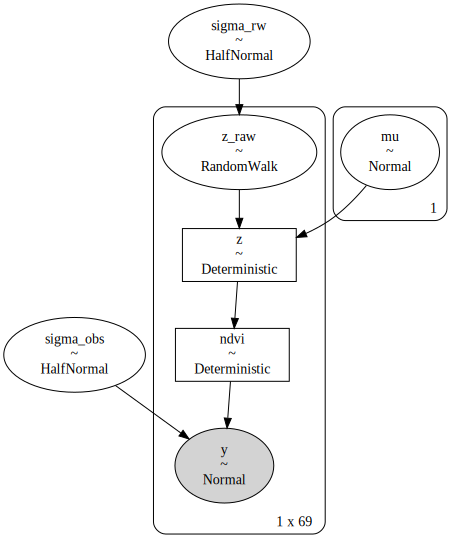

In [128]:
pm.model_to_graphviz(model)

In [129]:
for rv in model.free_RVs:
    print(rv.name, rv.eval().shape)

sigma_obs ()
sigma_rw ()
mu (1,)
z_raw (1, 69)


### pruebo con series conocidas

bosque

In [130]:
bosques = series[0::2, :]
# bosque_model = build_model_rw2(bosques)
bosque_model = build_model_rw2_v3(bosques)

with bosque_model:
        idata = pm.sample(
            2000,
            tune=2000,
            target_accept=0.9)


# for bosque_ in bosques[:3, :]:
#     # plt.figure(figsize=(4,1))
#     # plt.plot(bosque_)
#     serie_prueba = bosque_
#     model = build_model_rw2(serie_prueba)
#     with model:
#         idata = pm.sample(
#             1000,
#             tune=500,
#             target_accept=0.9
#         )
#     est_series = idata.posterior["ndvi"].mean(dim=["chain", "draw"])
#     plt.figure(figsize=(4,1))
#     plt.plot(bosque_,'g')
#     plt.plot(est_series.values[0],'r')    


/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/pymc/distributions/timeseries.py:298: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_obs, sigma_rw, mu, z_raw]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 110 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'sigma_obs'}>,
        <Axes: title={'center': 'sigma_obs'}>],
       [<Axes: title={'center': 'sigma_rw'}>,
        <Axes: title={'center': 'sigma_rw'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

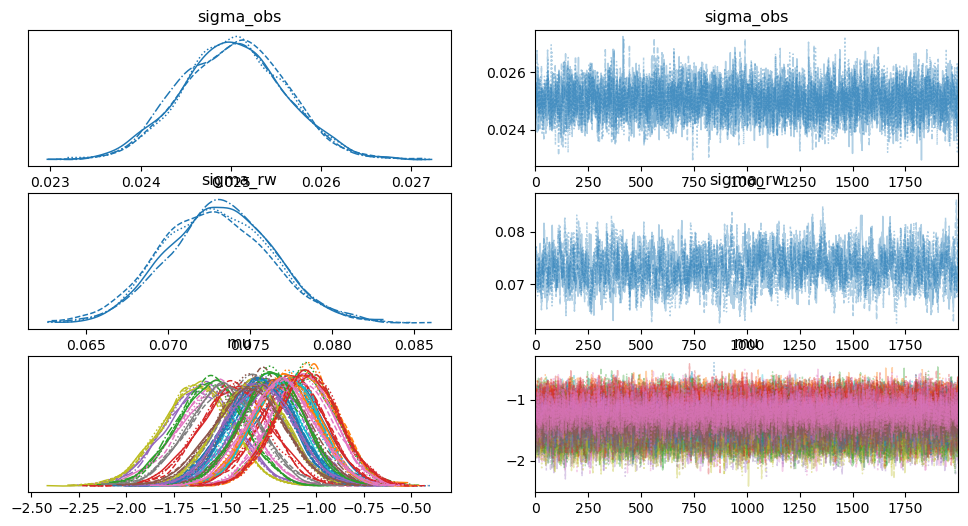

In [131]:
import arviz as az
az.plot_trace(idata, var_names=["sigma_obs", "sigma_rw", "mu"])

In [132]:
az.summary(idata, var_names=["sigma_obs", "sigma_rw", "mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_obs,0.025,0.001,0.024,0.026,0.000,0.000,2766.0,5897.0,1.00
sigma_rw,0.073,0.003,0.067,0.079,0.000,0.000,669.0,1601.0,1.01
mu[0],-1.160,0.176,-1.505,-0.841,0.002,0.002,6225.0,5448.0,1.00
mu[1],-1.160,0.169,-1.478,-0.854,0.002,0.002,6117.0,5668.0,1.00
mu[2],-1.059,0.165,-1.363,-0.747,0.002,0.002,5676.0,5324.0,1.00
mu[3],-1.127,0.174,-1.449,-0.793,0.002,0.002,6466.0,5448.0,1.00
mu[4],-1.610,0.188,-1.967,-1.268,0.002,0.002,5698.0,5534.0,1.00
mu[5],-1.292,0.174,-1.612,-0.963,0.002,0.002,6555.0,5326.0,1.00
mu[6],-1.539,0.190,-1.904,-1.194,0.002,0.002,6724.0,5133.0,1.00
mu[7],-1.343,0.176,-1.665,-0.996,0.003,0.002,4376.0,5141.0,1.00


reconstruyo la serie

In [133]:
idata.posterior["ndvi"].mean(dim=["chain", "draw"])

<xarray.DataArray 'ndvi' (ndvi_dim_0: 27, ndvi_dim_1: 69)> Size: 15kB
array([[0.2466757 , 0.25706133, 0.26714832, ..., 0.1929165 , 0.20982934,
        0.22862583],
       [0.24752372, 0.25855977, 0.27249052, ..., 0.17845875, 0.17151566,
        0.16768574],
       [0.27749963, 0.30046846, 0.31837482, ..., 0.2213805 , 0.21020683,
        0.19917736],
       ...,
       [0.22274575, 0.23418619, 0.2507888 , ..., 0.18503129, 0.17824097,
        0.17502967],
       [0.21202319, 0.22252431, 0.24198257, ..., 0.19573397, 0.18804632,
        0.18451266],
       [0.24393764, 0.25528735, 0.2760017 , ..., 0.17577117, 0.17200042,
        0.17220196]])
Coordinates:
  * ndvi_dim_0  (ndvi_dim_0) int64 216B 0 1 2 3 4 5 6 7 ... 20 21 22 23 24 25 26
  * ndvi_dim_1  (ndvi_dim_1) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68

In [134]:
est_series = idata.posterior["ndvi"].mean(dim=["chain", "draw"])

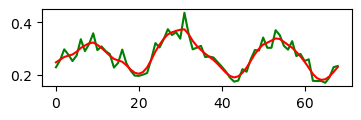

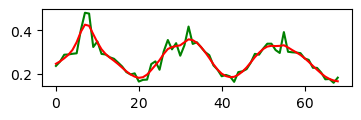

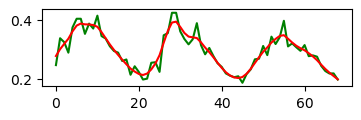

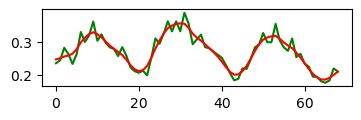

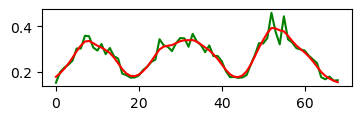

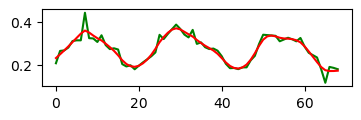

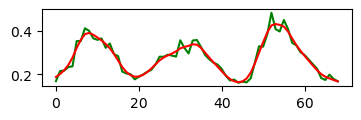

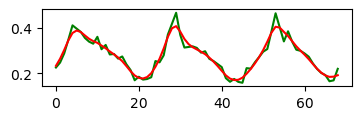

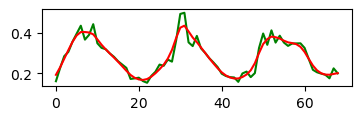

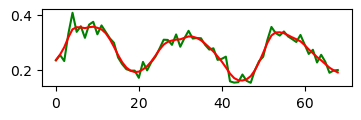

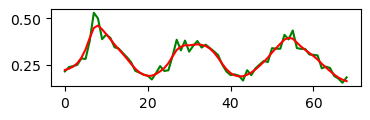

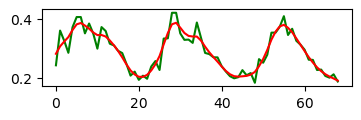

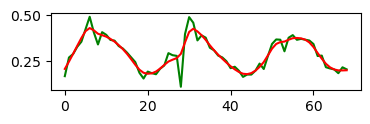

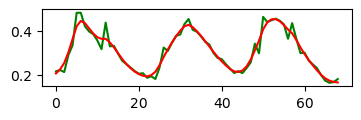

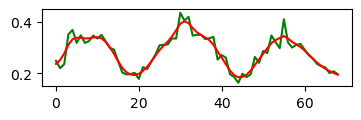

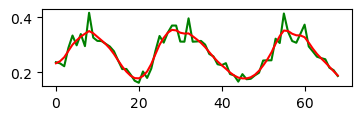

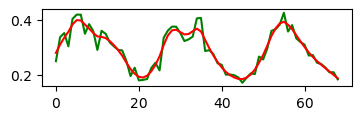

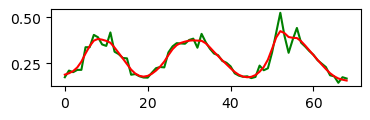

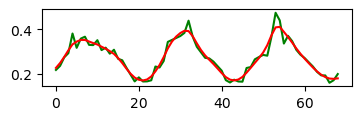

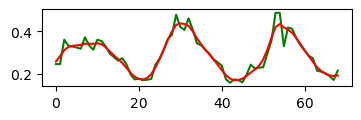

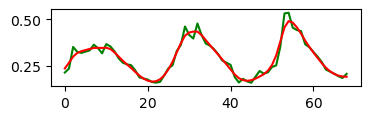

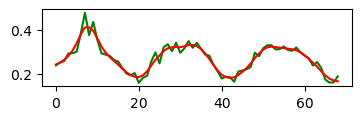

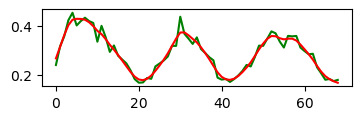

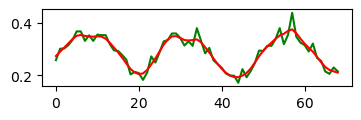

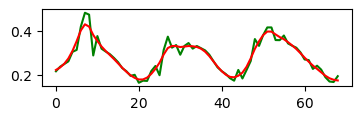

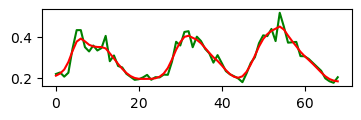

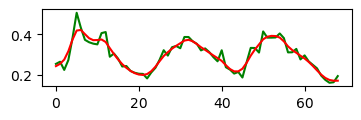

In [135]:
if True:   
    for b_ in range(bosques.shape[0]):
        plt.figure(figsize=(4,1))
        plt.plot(bosques[b_,:],'g')
        plt.plot(est_series.values[b_,:],'r')
        plt.show()

quiero estudiar el valor de las varaibles a clusterizar

Clusterizo todas las series

In [ ]:
def build_model_dp_rw2(series_values,
                       MAX_CLUSTERS=6,
                       ALPHA_DP=1.0):

    """
    DP clustering de series de tiempo con modelo temporal RW2 por cluster
    """

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pm.math.concatenate(
                [beta[:1],
                 beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignment
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 per cluster
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T-1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        x = pt.concatenate(
            [mu[:, None], mu[:, None] + rw2],
            axis=1
        )

        x = pm.Deterministic("x", x)

        # -----------------------------
        # likelihood
        # -----------------------------

        for i in range(n_series):

            mu_i = x[z[i]]

            pm.Normal(
                f"y_{i}",
                mu=mu_i,
                sigma=sigma_obs[z[i]],
                observed=series_values[i]
            )

    return model

In [ ]:
def build_model_dp_rw2_vectorized(series_values,
                                  MAX_CLUSTERS=6,
                                  ALPHA_DP=1.0):

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick-breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pt.concatenate(
                [
                    beta[:1],
                    beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])
                ]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignments
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 temporal process
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T - 1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        # version unbounded ------------------------------------
        # x = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        # x = pm.Deterministic("x", x)

        # version bounded ------------------------------------
        eta = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        x = pm.Deterministic("x", pm.math.sigmoid(eta))

        # -----------------------------
        # select cluster trajectory
        # -----------------------------

        mu_series = x[z]              # shape (n_series, T)
        sigma_series = sigma_obs[z]   # shape (n_series,)

        # -----------------------------
        # likelihood vectorizada
        # -----------------------------

        pm.Normal(
            "y",
            mu=mu_series,
            sigma=sigma_series[:, None],
            observed=series_values
        )

    return model

In [ ]:
series.shape

In [ ]:
# clusterModel = build_model_dp_rw2(series)
clusterModel = build_model_dp_rw2_vectorized(series,
                                  MAX_CLUSTERS=5,
                                  ALPHA_DP=3.0)

In [ ]:
for rv in clusterModel.free_RVs:
    print(rv.name, rv.eval().shape)

In [ ]:
with clusterModel:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9
    )

In [ ]:
import arviz as az
# az.summary(trace, var_names=["z"])
az.summary(trace, var_names=["sigma_rw", "sigma_obs", "mu"])

# az.summary(trace)

In [ ]:
trace.posterior

In [ ]:
z_post = trace.posterior["z"].mean(dim=("chain","draw")).values
z_est = np.round(z_post).astype(int)

In [ ]:
print("True clusters:")
print(true_clusters)
print("Estimated clusters:")
print(z_est)
print("Estimated N:", len(np.unique(z_est)))

### Evaluacion clusters

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def aligned_confusion(true_labels, est_labels):
    true_labels = np.array(true_labels)
    est_labels  = np.array(est_labels)

    cm = confusion_matrix(true_labels, est_labels)

    # Hungarian algorithm → maximizar diagonal
    row_ind, col_ind = linear_sum_assignment(-cm)

    aligned_cm = cm[:, col_ind]
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

    aligned_est = np.array([mapping[e] for e in est_labels])

    return aligned_cm, aligned_est, mapping


In [ ]:
def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Estimated cluster")
    plt.ylabel("True cluster")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j],
                     ha="center", va="center",
                     fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
uniques = np.unique(z_est)

In [ ]:
# z_est[z_est == 4] = 3

In [ ]:
cm, aligned_est, mapping = aligned_confusion(true_clusters, z_est)

print("Cluster mapping:", mapping)
plot_confusion(cm)


Evaluacion series de tiempo

In [ ]:
def extract_cluster_signatures(trace, z_est):

    x_post = trace.posterior["x"]

    # media posterior
    x_mean = x_post.mean(dim=("chain","draw")).values

    # desviación estándar posterior
    x_std = x_post.std(dim=("chain","draw")).values

    # tamaño de clusters
    clusters = np.unique(z_est)
    cluster_size = {k: np.sum(z_est == k) for k in clusters}

    signatures = {}

    for k in clusters:

        signatures[k] = {
            "mean": x_mean[k],
            "std": x_std[k],
            "size": cluster_size[k]
        }

    return signatures

In [ ]:
# import matplotlib.pyplot as plt

def plot_cluster_signatures(signatures):

    for k, s in signatures.items():

        mu = s["mean"]
        sd = s["std"]
        n  = s["size"]

        t = np.arange(len(mu))

        plt.plot(t, mu, label=f"cluster {k} (n={n})")

        plt.fill_between(
            t,
            mu - 1*sd,
            mu + 1*sd,
            alpha=0.2
        )

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.2)
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.2)

    plt.ylim(0.1, 0.6)
    plt.xlabel("time")
    plt.ylabel("NDVI")
    plt.legend()
    plt.show()

In [ ]:
signatures = extract_cluster_signatures(trace, z_est)

plot_cluster_signatures(signatures)

In [ ]:
def plot_cluster_ndvi_posterior(trace, z_est, ci=0.9):
    """
    trace   : trace de PyMC
    z_est   : cluster asignado por serie
    """

    a_post = trace.posterior["a"].stack(sample=("chain","draw")).values
    # shape = (Kmax, N_segments, n_samples)

    clusters = np.unique(z_est)
    # bins = np.floor((days % 365) / 365 * n_segments).astype(int)

    plt.figure(figsize=(10,4))
    
    for k in clusters:

        samples = a_post[k, quincenas[:23], :]  # (365, n_samples)

        mean = samples.mean(axis=1)
        low  = np.percentile(samples, (1-ci)/2*100, axis=1)
        high = np.percentile(samples, (1+(ci))/2*100, axis=1)

        n_series = np.sum(z_est == k)

        plt.plot(quincenas[:23], mean, label=f"Cluster {k} (n={n_series})")
        plt.fill_between(quincenas[:23], low, high, alpha=0.25)

    # series reales
    # plt.plot(quincenas[:23], series[true_clusters, :23].mean(axis=0), color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas[:23], series[true_clusters == 1, :].T[:23], color='red', alpha=0.1)
    # plt.plot(quincenas[:23], series[true_clusters == 2, :].T[:23], color='blue', alpha=0.1)

    #Este anda!
    # plt.plot(quincenas, series[0::2, :23].mean(axis=0), linestyle=':', color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas, series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.1) #, label="Bosque medio"
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.1) #, label="No Bosque medio"

    plt.xlim(0, 23)
    plt.ylim(0.1, 0.6)

    plt.xlabel("Quincena")
    plt.ylabel("NDVI")
    plt.title("NDVI promedio por cluster (posterior PyMC)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
plot_cluster_ndvi_posterior(trace, z_est, ci=0.9)

In [ ]:
series[true_clusters, :23].mean(axis=0)

In [ ]:
series[1::2, :23].shape

In [ ]:
plt.plot(quincenas[:23], series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")


In [ ]:
quincenas.shape

In [ ]:
plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.5, label="Bosque medio")
plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.5, label="No Bosque medio")